# HDCytoData — Samusik_01

The original paper can be found here: https://www.todo.com

__Abstract__: TODO

## 0. Imports & Set-Up:

In [1]:
import multiprocessing
import random
import inspect

from collections import Counter
from typing import List, Tuple, Type
from joblib import Parallel, delayed

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, confusion_matrix, davies_bouldin_score, pairwise_distances, silhouette_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import check_random_state

from scipy.optimize import linear_sum_assignment

from umap import UMAP

import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad, io, gzip, os

import matplotlib.pyplot as plt

from carve import CARVE
from carve.config import ValidatorConfig

from pathlib import Path

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [3]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [5]:
def gamma_quantiles_approx(
    X: np.ndarray,
    qs: Tuple[float, ...] = (0.05, 0.10, 0.25, 0.50),
    max_points: int = 500,
    random_state: int = 0,
) -> List[float]:
    rng = check_random_state(random_state)
    n = X.shape[0]
    Xs = X[rng.choice(n, size=max_points, replace=False)] if n > max_points else X

    D2 = pairwise_distances(Xs, metric="sqeuclidean")
    d2 = D2[np.triu_indices_from(D2, k=1)]
    d2 = d2[np.isfinite(d2)]
    if d2.size == 0:
        return [1.0 for _ in qs]
    return [float(1.0 / (2.0 * np.quantile(d2, q))) for q in qs]

The following cell defines a custom `LeidenClustering` class, providing a scikit-learn style interface to the Leiden community detection algorithm. This approach enables clustering of tabular data by first constructing a k-nearest neighbor (kNN) graph and then applying Leiden for community detection.

The custom `LeidenClustering` class:
- Accepts standard sklearn parameters (`n_clusters`, `n_neighbors`, `resolution`, `random_state`).
- Builds an undirected kNN graph from the input data.
- Runs Leiden via the `leidenalg` package on the constructed graph.
- Optionally relabels clusters to match the requested number of clusters (`n_clusters`), mapping the largest clusters to consecutive labels.
- Is compatible with sklearn workflows (`fit`, `fit_predict`).

This wrapper is used for benchmarking Leiden clustering alongside other sklearn algorithms below.

In [6]:
from sklearn.base import BaseEstimator
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors

class LeidenClustering(BaseEstimator, ClusterMixin):
    """
    Wrapper for Leiden community detection algorithm with sklearn interface.
    Clusters tabular data by building a k-nearest neighbor graph and running Leiden.

    Parameters:
        n_clusters (int): Desired number of clusters (approximate, Leiden may not match exactly).
        n_neighbors (int): Number of neighbors for graph construction (default: 10).
        resolution (float): Resolution parameter for Leiden (higher = more clusters, default: 1.0).
        random_state (int or None): Random seed.
    """
    def __init__(self, n_clusters=None, n_neighbors=10, resolution=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.n_neighbors = n_neighbors
        self.resolution = resolution
        self.random_state = random_state

    def fit(self, X, y=None):
        # Build kNN graph
        knn = NearestNeighbors(n_neighbors=self.n_neighbors + 1, metric='euclidean')
        knn.fit(X)
        knn_graph = knn.kneighbors_graph(X, mode='connectivity')
        sources, targets = knn_graph.nonzero()
        edges = list(zip(sources.tolist(), targets.tolist()))

        # Create igraph graph
        g = ig.Graph(n=X.shape[0], edges=edges, directed=False)
        g.simplify()

        # Run Leiden
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=self.resolution,
            seed=self.random_state
        )
        self.labels_ = np.array(partition.membership)

        # Optionally, relabel to match n_clusters if specified
        if self.n_clusters is not None and len(np.unique(self.labels_)) != self.n_clusters:
            # Map largest clusters to 0..n_clusters-1, rest to -1
            counts = np.bincount(self.labels_)
            top = np.argsort(counts)[::-1][:self.n_clusters]
            mapping = {old: new for new, old in enumerate(top)}
            self.labels_ = np.array([mapping.get(l, -1) for l in self.labels_])

        return self

    def fit_predict(self, X, y=None):
        self.fit(X, y)
        return self.labels_

`align_labels` aligns arbitrary cluster labels to a set of reference labels by maximizing agreement via the Hungarian algorithm. This is useful because clustering algorithms assign label IDs arbitrarily, and direct comparison to true labels requires a permutation alignment.

**Inputs**
- `true_labels` (`np.ndarray`): Ground-truth labels for each sample (preferably integer-coded, e.g., `pd.Categorical(...).codes`).
- `pred_labels` (`np.ndarray`): Predicted cluster labels for each sample (arbitrary IDs).

**Process**
1. Computes the confusion matrix `cm` between `true_labels` and `pred_labels`.
2. Applies the Hungarian algorithm (`linear_sum_assignment`) to `-cm` to find the permutation of predicted labels that maximizes total matches.
3. Builds a mapping from predicted labels to matched true labels.
4. Re-labels `pred_labels` according to this mapping; any predicted label not present in the mapping is left unchanged.

**Output**
- `np.ndarray`: Aligned predicted labels with IDs permuted to best match `true_labels` (same shape as `pred_labels`).

In [7]:
def align_labels(true_labels, pred_labels):
    """
    Aligns predicted cluster labels to true labels by maximizing agreement using the Hungarian algorithm.

    Args:
        true_labels (np.ndarray): Ground-truth labels for each sample (integer-coded).
        pred_labels (np.ndarray): Predicted cluster labels for each sample (arbitrary IDs).

    Returns:
        np.ndarray: Aligned predicted labels with IDs permuted to best match true_labels.
    """
    cm = confusion_matrix(true_labels, pred_labels)
    
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    label_map = {old: new for old, new in zip(col_ind, row_ind)}
    return np.array([label_map[l] if l in label_map else l for l in pred_labels])

The following functions implement the **Gap Statistic** method for determining the optimal number of clusters in a dataset.  
They work together to quantify how much better the observed clustering is compared to what would be expected under a reference (null) distribution with no inherent structure.

##### Function 1: `compute_dispersion`
Computes the within-cluster dispersion measure \( W_k \), which quantifies how tightly points are grouped within each cluster.

**Inputs**
- `X` (`np.ndarray`): Data matrix with samples as rows and features as columns.  
- `labels` (`np.ndarray`): Cluster labels for each observation.  
- `metric` (`str`, default `'euclidean'`): Distance metric used to compute pairwise distances within clusters.

**Process**
1. Iterates over all unique cluster labels.  
2. For each cluster, computes all pairwise distances between points.  
3. Averages the total within-cluster distances, normalized by the number of points.  
4. Sums these values across clusters to obtain total within-cluster dispersion.

**Output**
- Returns a single float `W_k`: the total within-cluster dispersion.

##### Function 2: `gen_null`
Generates a reference dataset (null model) by independently sampling each feature from a uniform distribution spanning the observed feature range.

**Inputs**
- `X` (`np.ndarray`): Original dataset.  
- `_` (`int`): Placeholder (unused).  
- `random_state` (`int`): Seed for reproducibility.

**Process**
1. For each feature (column), samples uniformly between its observed minimum and maximum.  
2. Produces a dataset with the same shape as `X` but without clustering structure.

**Output**
- Returns `X_ref` (`np.ndarray`): Null (reference) dataset.

##### Function 3: `gap_statistic`
Computes the Gap Statistic comparing observed clustering dispersion to that expected under the null model.

**Inputs**
- `X` (`np.ndarray`): Data matrix.  
- `labels` (`np.ndarray`): Cluster labels from a fitted clustering algorithm.  
- `metric` (`str`, default `'euclidean'`): Distance metric for dispersion calculation.  
- `n_refs` (`int`, default `10`): Number of reference datasets to generate.  
- `algorithm` (`Type[ClusterMixin]`, default `KMeans`): Clustering algorithm used for reference clustering.  
- `random_state` (`int` or `None`): Random seed for reproducibility.

**Process**
1. Computes observed within-cluster dispersion `W_k`.  
2. Generates `n_refs` null datasets via `gen_null`.  
3. Clusters each null dataset and computes its log-dispersion.  
4. Estimates the expected log-dispersion under the null model.  
5. Computes the Gap Statistic:  
   $$
   \text{Gap}(k) = E[\log(W_k^{\text{null}})] - \log(W_k)
   $$
   Larger gaps indicate more distinct clustering structure than expected by chance.

**Output**
- Returns a single float `gap`: the computed Gap Statistic value for the given clustering configuration.


In [8]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Computes the within-cluster dispersion measure W_k for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').

    Returns:
        float: Total within-cluster dispersion W_k.
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric, squared=True)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gen_null_box(X: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Uniform reference distribution over the axis-aligned bounding box of X."""
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    span = maxs - mins
    return rng.random(size=X.shape) * span + mins

def _pick_first(v):
    return v[0] if isinstance(v, (list, tuple)) else v

def _build_estimator(
    algorithm: Type[ClusterMixin],
    k: int,
    algorithm_params: dict | None,
    seed: int,
):
    # start with the fixed params coming from model_grids[0][1]
    params = {}
    if algorithm_params:
        for key, val in algorithm_params.items():
            if key == "n_clusters":
                continue
            
            params[key] = _pick_first(val)

    # set k for this call
    params["n_clusters"] = k

    # set random_state when supported
    sig = inspect.signature(algorithm.__init__)
    if "random_state" in sig.parameters:
        params["random_state"] = seed

    # pin kmeans defaults across sklearn versions
    if algorithm.__name__ == "KMeans" or algorithm is KMeans:
        if "n_init" in sig.parameters and "n_init" not in params:
            params["n_init"] = 10

    return algorithm(**params)

def gap_statistic(
    X: np.ndarray,
    labels: np.ndarray,
    metric: str = "euclidean",
    n_refs: int = 10,
    algorithm: Type[ClusterMixin] = KMeans,
    algorithm_params: dict | None = None,
    random_state: int = 0,
) -> float:
    """
    Gap(k) = E[log W*_k] - log W_k, with W_k computed from provided labels.
    """
    rng = np.random.default_rng(int(random_state))

    W_k = compute_dispersion(X, labels, metric)
    if not np.isfinite(W_k) or W_k <= 0:
        return np.nan

    k = int(np.unique(labels).size)

    ref_log_disps = np.empty(n_refs, dtype=float)
    for b in range(n_refs):
        X_ref = gen_null_box(X, rng)
        seed_b = int(rng.integers(0, 2**32 - 1))

        est = _build_estimator(algorithm, k, algorithm_params, seed_b)
        ref_labels = est.fit_predict(X_ref)

        W_ref = compute_dispersion(X_ref, ref_labels, metric)
        ref_log_disps[b] = np.log(W_ref)

    return float(np.mean(ref_log_disps) - np.log(W_k))

`davies_bouldin_inv` computes a normalized, "higher-is-better" variant of the Davies–Bouldin index for a given clustering. It transforms the standard Davies–Bouldin score `db` into

$$
\frac{1}{1 + \textit{Davies–Bouldin Index}}
$$

, so tighter, well-separated clusters yield values closer to 1, while worse clusterings approach 0.

##### Inputs
- `X` (np.ndarray): Data matrix with shape (n_samples, n_features).
- `labels` (np.ndarray): Cluster labels for each sample.

##### What It Computes
1. Calls `davies_bouldin_score(X, labels)` to get `db` (lower is better).
2. Transforms to an increasing metric: `score = 1 / (1 + db)`.
3. If `db` is not finite, returns `np.nan`.

##### Output
- `float`: Inverse Davies–Bouldin score in (0, 1] when finite, else `np.nan`. Higher values indicate more compact and well-separated clusters.


In [9]:
def davies_bouldin_inv(X: np.ndarray, labels: np.ndarray) -> float:
    """
    Computes the inverse Davies-Bouldin index for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.

    Returns:
        float: Inverse Davies-Bouldin score (1 / (1 + db)), higher is better. Returns np.nan if db is not finite.
    """
    db = davies_bouldin_score(X, labels)
    return 1.0 / (1.0 + db) if np.isfinite(db) else np.nan

---

## 1. Pre-Process the Data

In [10]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

ro.r(r'''
if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager")
if (!requireNamespace("HDCytoData", quietly=TRUE)) BiocManager::install("HDCytoData")
library(HDCytoData)
library(SummarizedExperiment)
''')

ro.r("sce <- Samusik_01_SE()")

X = np.array(ro.r("assay(sce)"), dtype=float)

row_df = pandas2ri.rpy2py(ro.r("as.data.frame(rowData(sce))"))
print("rowData columns:", list(row_df.columns))

# use the actual population labels
y = row_df["population_id"].astype(str).to_numpy()

print("X:", X.shape, "y:", y.shape, "unique labels:", len(np.unique(y)))
print("top label counts:\n", row_df["population_id"].value_counts().head(10))

R callback write-console: Loading required package: ExperimentHub
  
R callback write-console: Loading required package: BiocGenerics
  
R callback write-console: Loading required package: generics
  
R callback write-console: 
Attaching package: ‘generics’

  
R callback write-console: The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union

  
R callback write-console: 
Attaching package: ‘BiocGenerics’

  
R callback write-console: The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

  
R callback write-console: The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames,

rowData columns: ['sample_id', 'population_id']
X: (86864, 51) y: (86864,) unique labels: 25
top label counts:
 population_id
25    33691
5     13607
15    12045
13     8768
8      5173
12     3508
23     2974
14     1123
22     1016
21      961
Name: count, dtype: int64


In [11]:
print(f"np.unique(y): {np.unique(y)}")
print(f"len(np.unique(y)): {len(np.unique(y))}")

np.unique(y): ['1' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '2' '20' '21' '22'
 '23' '24' '25' '3' '4' '5' '6' '7' '8' '9']
len(np.unique(y)): 25


In [12]:
col_df = pandas2ri.rpy2py(ro.r("as.data.frame(colData(sce))"))
print(col_df.columns, "\n")
print(col_df.head())

Index(['channel_name', 'marker_name', 'marker_class'], dtype='object') 

            channel_name  marker_name  marker_class
Time                Time         Time             1
Cell_length  Cell_length  Cell_length             1
BC1            (Pd102)Di          BC1             1
BC2            (Pd104)Di          BC2             1
BC3            (Pd105)Di          BC3             1


In [13]:
keep = (col_df["marker_class"].astype(int) == 2).to_numpy()
X = X[:, keep]

print("original X:", X.shape)
print("marker-only X:", X.shape)
print("kept markers:", col_df.index[keep].tolist()[:10], "...")
print("dropped:", col_df.index[~keep].tolist())

original X: (86864, 39)
marker-only X: (86864, 39)
kept markers: ['Ter119', 'CD45.2', 'Ly6G', 'IgD', 'CD11c', 'F480', 'CD3', 'NKp46', 'CD23', 'CD34'] ...
dropped: ['Time', 'Cell_length', 'BC1', 'BC2', 'BC3', 'BC4', 'BC5', 'BC6', 'DNA1', 'DNA2', 'Cisplatin', 'beadDist']


---

## 2. Analyse Data

In [14]:
v = X.var(axis=0)
print("top variances:", np.sort(v)[-10:])

print("max/median variance ratio:", v.max() / np.median(v))

print("near-constant features:", np.sum(v < 1e-12))

top variances: [ 2430.96085736  2725.74605031  3031.60218021  6833.66301365
  9349.21402623 13169.82785656 14483.84491155 34968.54931614
 49101.26815185 88702.07531494]
max/median variance ratio: 334.26894417881766
near-constant features: 0


In [15]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

X0 = X.astype(np.float64)

# drop (near-)constant features
# std = X0.std(axis=0)
# keep = std > 1e-12
# X0 = X0[:, keep]

# arcsinh transform (CyTOF typical cofactor = 5)
cofactor = 5.0
X1 = np.arcsinh(X0 / cofactor)

# robust scaling per marker (median/IQR-ish)
scaler = RobustScaler(quantile_range=(10, 90))
X2 = scaler.fit_transform(X1)

X = X2

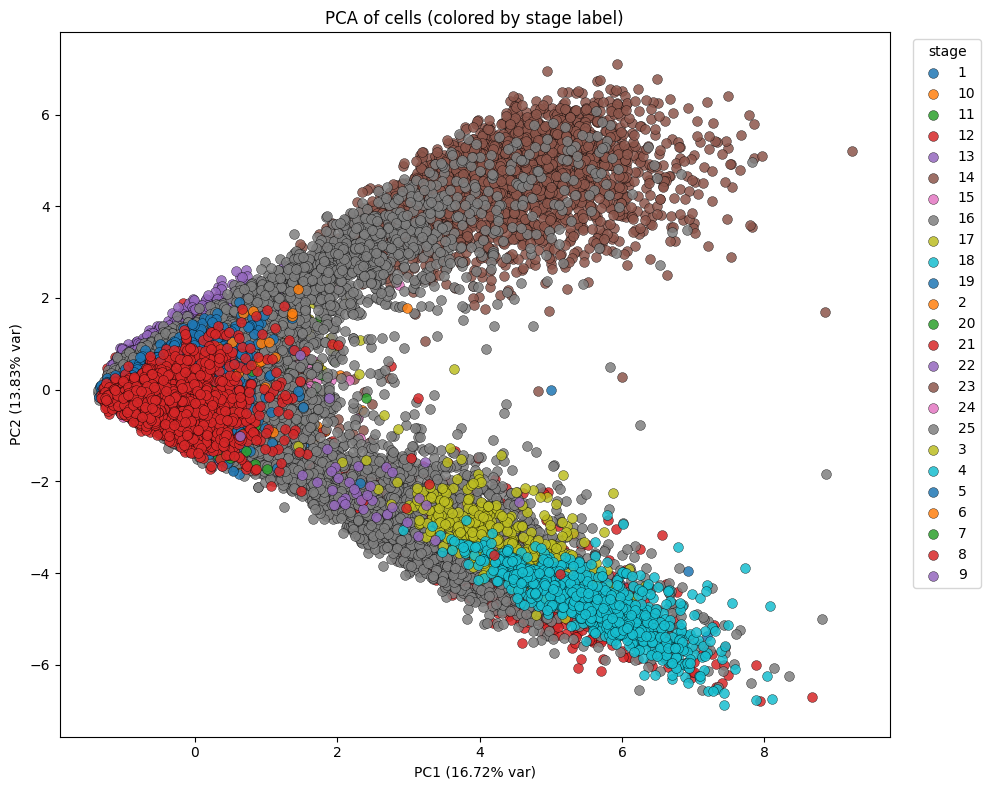

In [16]:
pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.4 Perform Clustering with "Oracle" Number of Clusters:

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_SEED)
sub_idx = next(sss.split(X, y))[1]

X_sub = X[sub_idx]
y_sub = y[sub_idx]

print("Subsampled X shape:", X_sub.shape)
print("Subsampled y shape:", y_sub.shape)
print("Label distribution in subsample:", pd.Series(y_sub).value_counts().head())

Subsampled X shape: (8687, 39)
Subsampled y shape: (8687,)
Label distribution in subsample: 25    3369
5     1361
15    1204
13     877
8      517
Name: count, dtype: int64


In [33]:
n_clusters = len(np.unique(y))

# KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED)
kmeans_labels = kmeans.fit_predict(X_sub)
ari_kmeans = adjusted_rand_score(y_sub, kmeans_labels)

# Agglomerative (Ward linkage)
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agg_labels = agg.fit_predict(X_sub)
ari_agg = adjusted_rand_score(y_sub, agg_labels)

# Leiden
leiden = LeidenClustering(n_clusters=n_clusters, random_state=RANDOM_SEED)
leiden_labels = leiden.fit_predict(X_sub)
ari_leiden = adjusted_rand_score(y_sub, leiden_labels)

# Spectral Clustering (median heuristic for gamma)
gamma = gamma_quantiles_approx(X_sub, qs=(0.50,), random_state=RANDOM_SEED)[0]
spectral = SpectralClustering(n_clusters=n_clusters, affinity='rbf', gamma=gamma, random_state=RANDOM_SEED)
spectral_labels = spectral.fit_predict(X_sub)
ari_spectral = adjusted_rand_score(y_sub, spectral_labels)

print(f"ARI KMeans: {ari_kmeans:.4f}")
print(f"ARI Agglomerative (Ward): {ari_agg:.4f}")
print(f"ARI Leiden: {ari_leiden:.4f}")
print(f"ARI Spectral (gamma={gamma:.6f}): {ari_spectral:.4f}")

ARI KMeans: 0.2177
ARI Agglomerative (Ward): 0.1391
ARI Leiden: 0.2153
ARI Spectral (gamma=0.029673): 0.1905


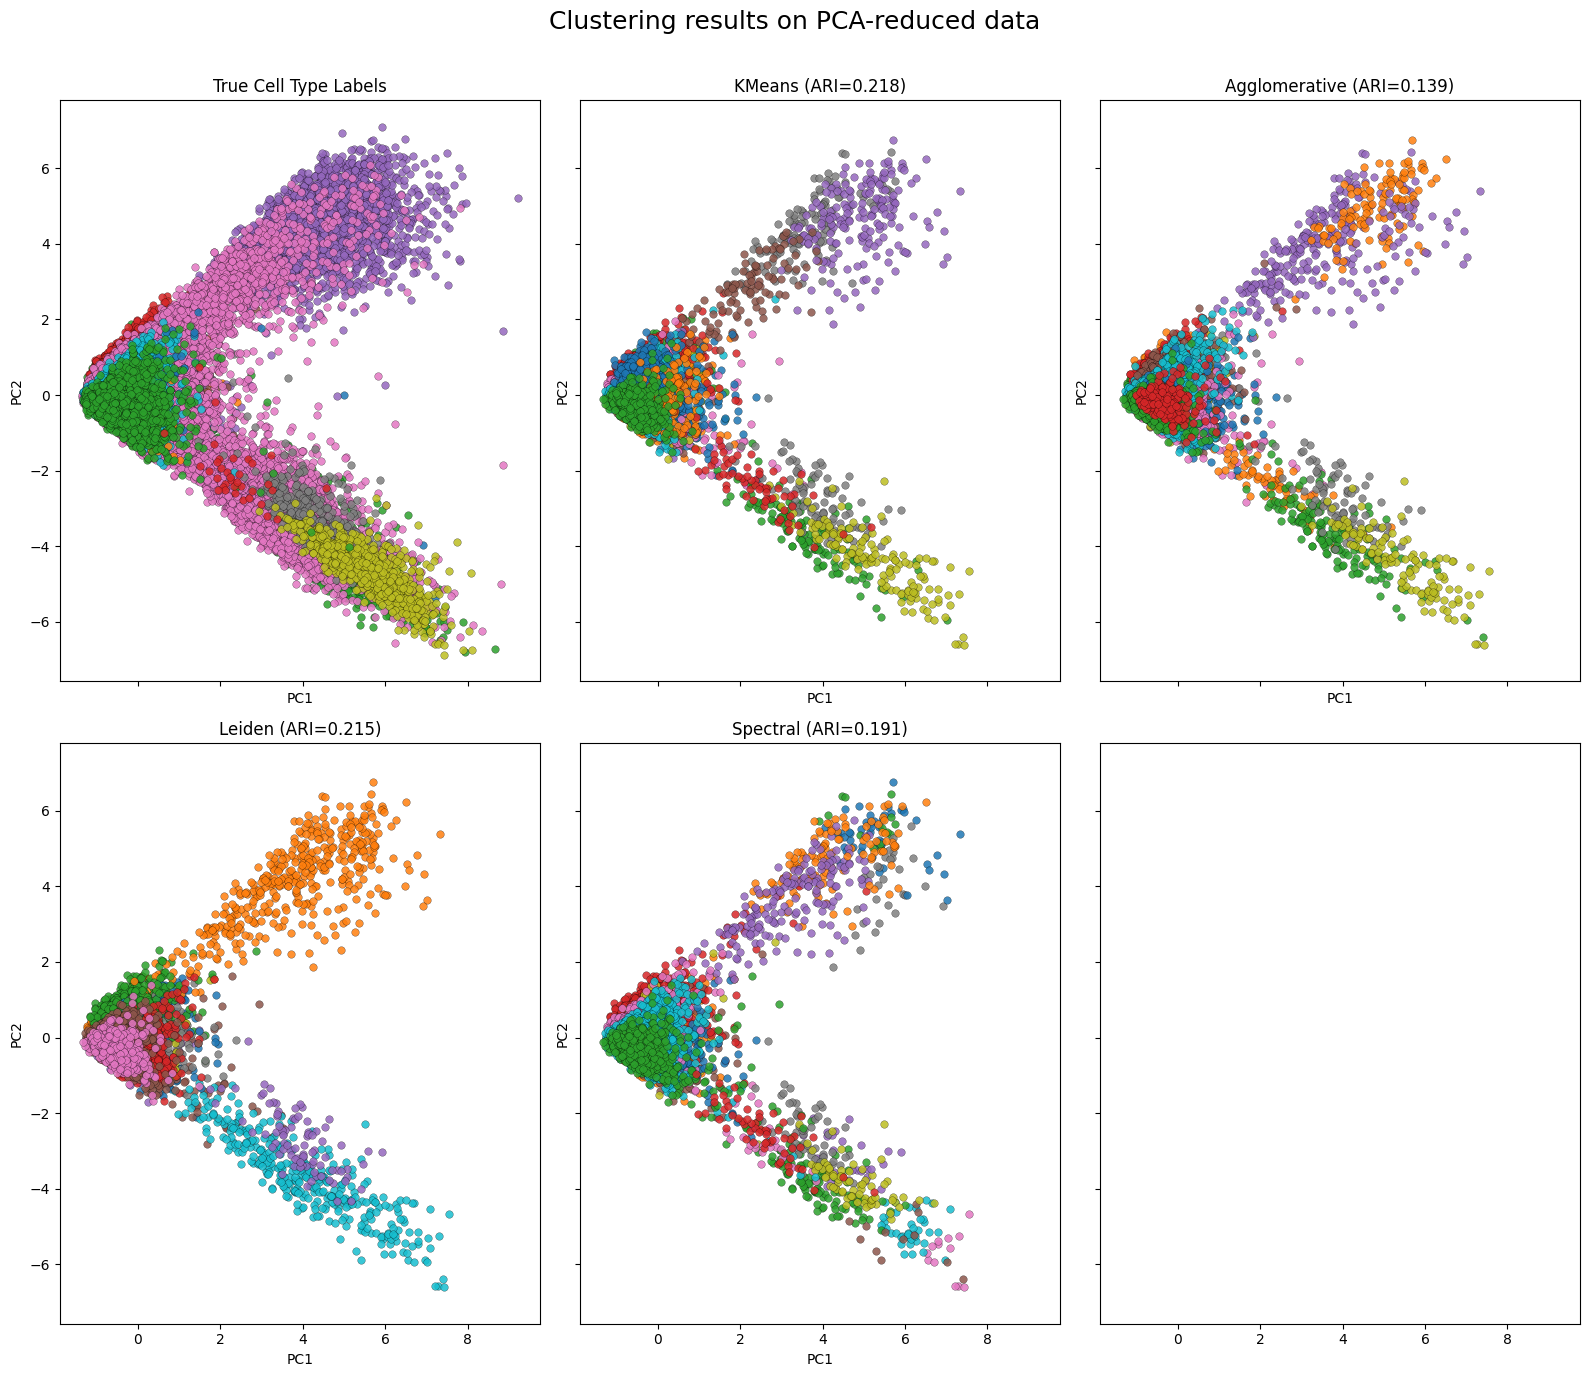

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 14), sharex=True, sharey=True)

# Plot true labels
pc_df_sub = pc_df.iloc[sub_idx].copy()
pc_df_sub['label'] = y_sub
ax_true = axes[0, 0]
for lab in pd.Categorical(y_sub).categories:
    sel = pc_df['label'] == lab
    ax_true.scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=lab)
ax_true.set_title("True Cell Type Labels")
ax_true.set_xlabel("PC1")
ax_true.set_ylabel("PC2")
# ax_true.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

titles = [
    f"KMeans (ARI={ari_kmeans:.3f})",
    f"Agglomerative (ARI={ari_agg:.3f})",
    f"Leiden (ARI={ari_leiden:.3f})",
    f"Spectral (ARI={ari_spectral:.3f})"
]
clusterings = [kmeans_labels, agg_labels, leiden_labels, spectral_labels]
aligned_clusterings = [align_labels(pd.Categorical(y_sub).codes, labels) for labels in clusterings]

for ax, labels, title in zip(axes.flat[1:], aligned_clusterings, titles):
    for cluster in np.unique(labels):
        sel = labels == cluster
        ax.scatter(
            pc_df_sub.loc[labels == cluster, 'PC1'],
            pc_df_sub.loc[labels == cluster, 'PC2'],
            s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=f"Cluster {cluster}"
        )
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    # ax.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.suptitle("Clustering results on PCA-reduced data", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

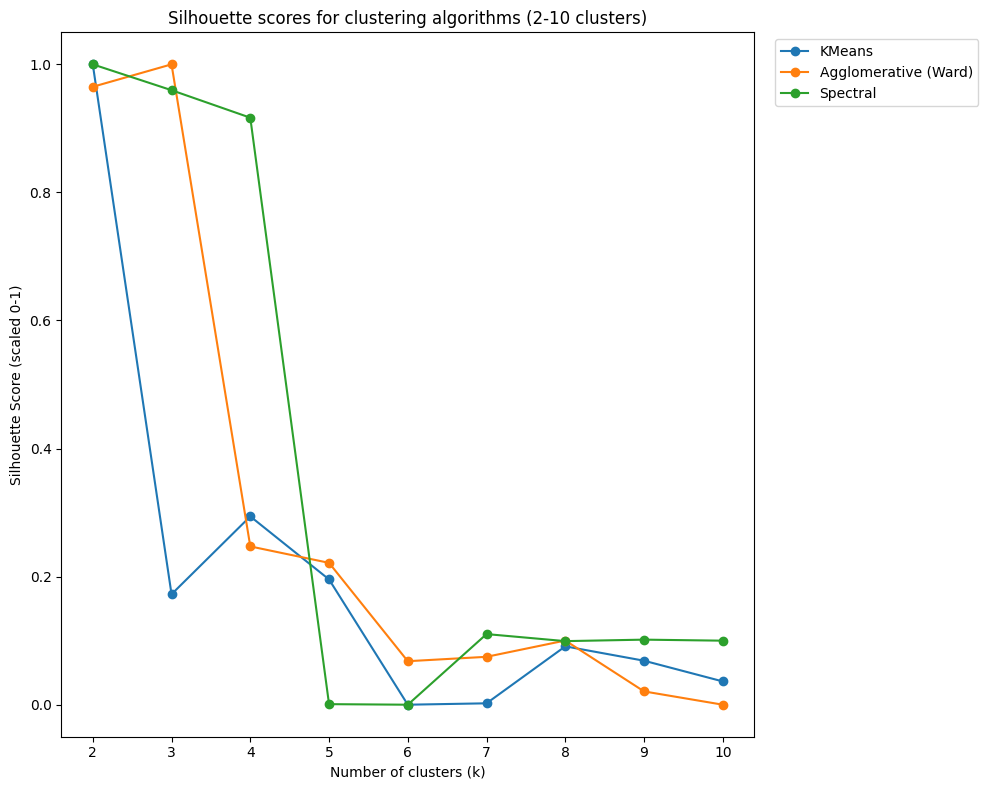

In [ ]:
ks = np.arange(2, 11)
silhouette_scores_kmeans = []
silhouette_scores_agg = []
silhouette_scores_spectral = []

for k in ks:
    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    labels_kmeans = kmeans.fit_predict(X_sub)
    sil_kmeans = silhouette_score(X_sub, labels_kmeans)
    silhouette_scores_kmeans.append(sil_kmeans)
    
    # Agglomerative (Ward)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_agg = agg.fit_predict(X_sub)
    sil_agg = silhouette_score(X_sub, labels_agg)
    silhouette_scores_agg.append(sil_agg)
    
    # Spectral Clustering (median heuristic for gamma)
    gamma = gamma_quantiles_approx(X_sub, qs=(0.50,), random_state=RANDOM_SEED)[0]
    spectral = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma, random_state=RANDOM_SEED)
    labels_spectral = spectral.fit_predict(X_sub)
    sil_spectral = silhouette_score(X_sub, labels_spectral)
    silhouette_scores_spectral.append(sil_spectral)

# Scale all scores to [0, 1]
scaler = MinMaxScaler()
silhouette_scores_kmeans_scaled = scaler.fit_transform(np.array(silhouette_scores_kmeans).reshape(-1, 1)).flatten()
silhouette_scores_agg_scaled = scaler.fit_transform(np.array(silhouette_scores_agg).reshape(-1, 1)).flatten()
silhouette_scores_spectral_scaled = scaler.fit_transform(np.array(silhouette_scores_spectral).reshape(-1, 1)).flatten()

plt.figure(figsize=(10, 8))
plt.plot(ks, silhouette_scores_kmeans_scaled, label='KMeans', marker='o')
plt.plot(ks, silhouette_scores_agg_scaled, label='Agglomerative (Ward)', marker='o')
plt.plot(ks, silhouette_scores_spectral_scaled, label='Spectral', marker='o')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score (scaled 0-1)')
plt.title('Silhouette scores for clustering algorithms (2-10 clusters)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---

## 4. Run CARVE:

In [18]:
ks = np.arange(2, 30+1)

model_grids = [
    (KMeans, {"n_clusters": ks}), 
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}), 
    (SpectralClustering, {"n_clusters": ks, "gamma": gamma_quantiles_approx(X_sub, qs=(0.50,), random_state=RANDOM_SEED)})
]

carve = CARVE(
    model_grids=model_grids,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED
)

carve.fit(X_sub, ref_labels=y_sub)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 8687
[CARVE] n_features         : 39
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 87
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/87] est=KMeans n_clusters=2 | ARI_stab=0.389±0.043  ARI_gen=0.341±0.038  ARI_avg=0.365±0.029
[CARVE] [2/87] est=KMeans n_clusters=3 | ARI_stab=0.498±0.030  ARI_gen=0.497±0.032  ARI_avg=0.498±0.024
[CARVE] [3/87] est=KMeans n_clusters=4 | ARI_stab=0.693±0.032  ARI_gen=0.708±0.030  ARI_avg=0.701±0.026
[CARVE] [4/87] est=KMeans n_clusters=5 | ARI_stab=0.863±0.016  ARI_gen=0.824±0.015  ARI_avg=0.843±0.012
[CARVE] [5/87] est=KMeans n_clusters=6 | ARI_stab=0.713±0.021  ARI_gen=0.640±0.020  ARI_

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



[CARVE] [59/87] est=SpectralClustering n_clusters=2 | ARI_stab=0.757±0.025  ARI_gen=0.500±0.037  ARI_avg=0.629±0.024
[CARVE] [60/87] est=SpectralClustering n_clusters=3 | ARI_stab=0.969±0.003  ARI_gen=0.885±0.004  ARI_avg=0.927±0.002
[CARVE] [61/87] est=SpectralClustering n_clusters=4 | ARI_stab=0.915±0.018  ARI_gen=0.827±0.020  ARI_avg=0.871±0.015
[CARVE] [62/87] est=SpectralClustering n_clusters=5 | ARI_stab=0.726±0.031  ARI_gen=0.606±0.030  ARI_avg=0.666±0.025
[CARVE] [63/87] est=SpectralClustering n_clusters=6 | ARI_stab=0.775±0.018  ARI_gen=0.642±0.013  ARI_avg=0.708±0.012
[CARVE] [64/87] est=SpectralClustering n_clusters=7 | ARI_stab=0.950±0.008  ARI_gen=0.871±0.009  ARI_avg=0.910±0.007
[CARVE] [65/87] est=SpectralClustering n_clusters=8 | ARI_stab=0.844±0.015  ARI_gen=0.775±0.011  ARI_avg=0.810±0.011
[CARVE] [66/87] est=SpectralClustering n_clusters=9 | ARI_stab=0.909±0.010  ARI_gen=0.830±0.011  ARI_avg=0.870±0.009
[CARVE] [67/87] est=SpectralClustering n_clusters=10 | ARI_stab=

python(22273) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(22495) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(22541) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(22544) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CARVE] [77/87] est=SpectralClustering n_clusters=20 | ARI_stab=0.620±0.011  ARI_gen=0.558±0.010  ARI_avg=0.589±0.008


python(22570) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(22619) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(22631) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(22655) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(22664) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CARVE] [78/87] est=SpectralClustering n_clusters=21 | ARI_stab=0.608±0.013  ARI_gen=0.559±0.011  ARI_avg=0.584±0.009


python(22718) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CARVE] [79/87] est=SpectralClustering n_clusters=22 | ARI_stab=0.592±0.012  ARI_gen=0.545±0.011  ARI_avg=0.568±0.009


python(22938) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(22958) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(22965) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CARVE] [80/87] est=SpectralClustering n_clusters=23 | ARI_stab=0.594±0.013  ARI_gen=0.556±0.011  ARI_avg=0.575±0.009


python(23155) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CARVE] [81/87] est=SpectralClustering n_clusters=24 | ARI_stab=0.602±0.011  ARI_gen=0.552±0.010  ARI_avg=0.577±0.008
[CARVE] [82/87] est=SpectralClustering n_clusters=25 | ARI_stab=0.628±0.012  ARI_gen=0.581±0.010  ARI_avg=0.604±0.008
[CARVE] [83/87] est=SpectralClustering n_clusters=26 | ARI_stab=0.608±0.013  ARI_gen=0.585±0.010  ARI_avg=0.597±0.009
[CARVE] [84/87] est=SpectralClustering n_clusters=27 | ARI_stab=0.638±0.012  ARI_gen=0.575±0.011  ARI_avg=0.606±0.009
[CARVE] [85/87] est=SpectralClustering n_clusters=28 | ARI_stab=0.615±0.013  ARI_gen=0.561±0.011  ARI_avg=0.588±0.009
[CARVE] [86/87] est=SpectralClustering n_clusters=29 | ARI_stab=0.567±0.012  ARI_gen=0.535±0.011  ARI_avg=0.551±0.009
[CARVE] [87/87] est=SpectralClustering n_clusters=30 | ARI_stab=0.596±0.013  ARI_gen=0.527±0.010  ARI_avg=0.561±0.009

[CARVE] finished. evaluated 87 model configurations.


,K,10
,B,100
,rho,0.6
,model_grids,"[(<class 'sklea...means.KMeans'>, ...), (<class 'sklea...veClustering'>, ...), ...]"
,norm_options,None
,dr_options,None
,ref_labels,"array(['15', ... dtype=object)"
,n_jobs,10
,random_state,42
,verbose,1


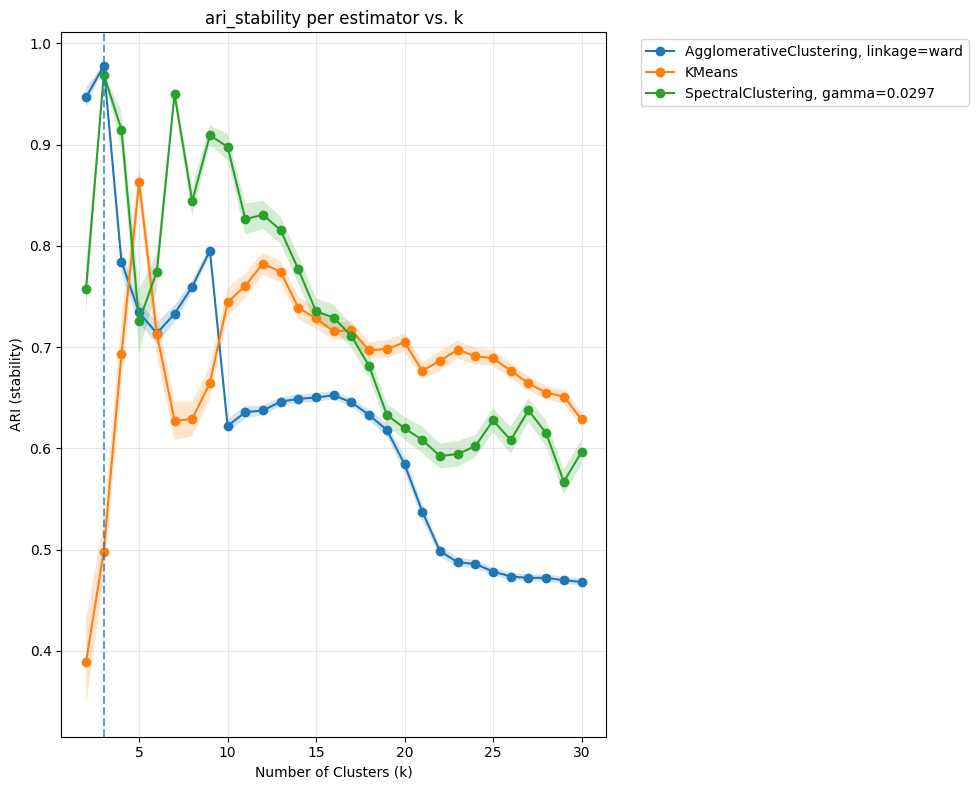

In [19]:
carve.plot_results(measure='ari_stability', rule='1se', interactive=False)

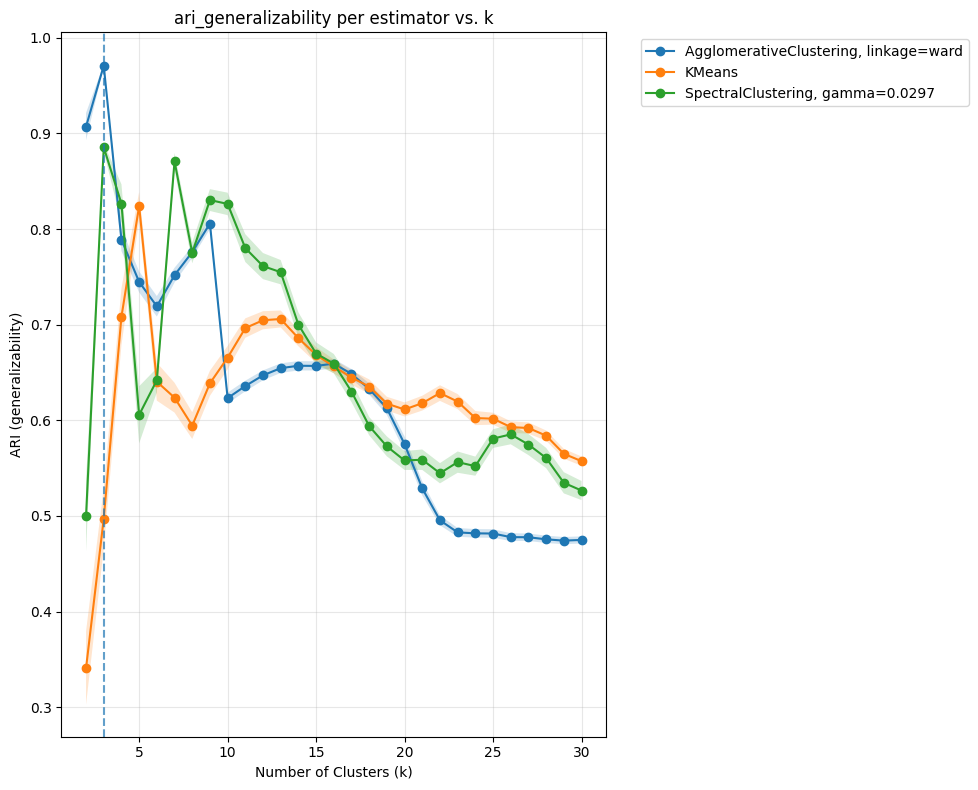

In [20]:
carve.plot_results(measure='ari_generalizability', rule='1se', interactive=False)

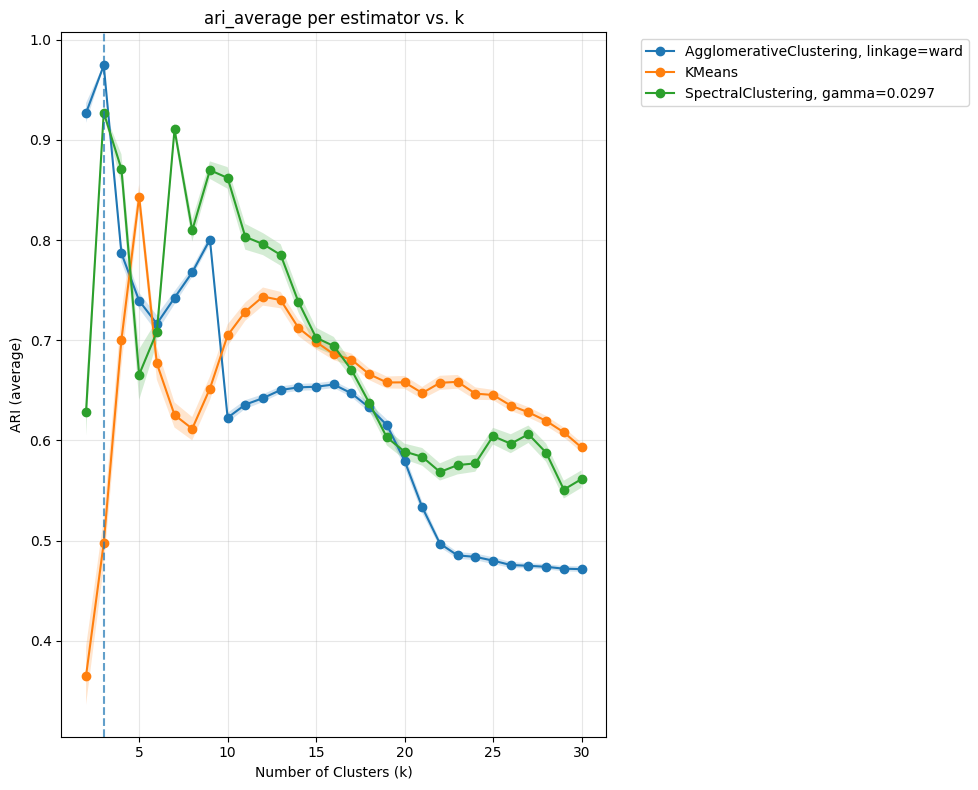

In [23]:
carve.plot_results(measure='ari_average', rule='1se', interactive=False)

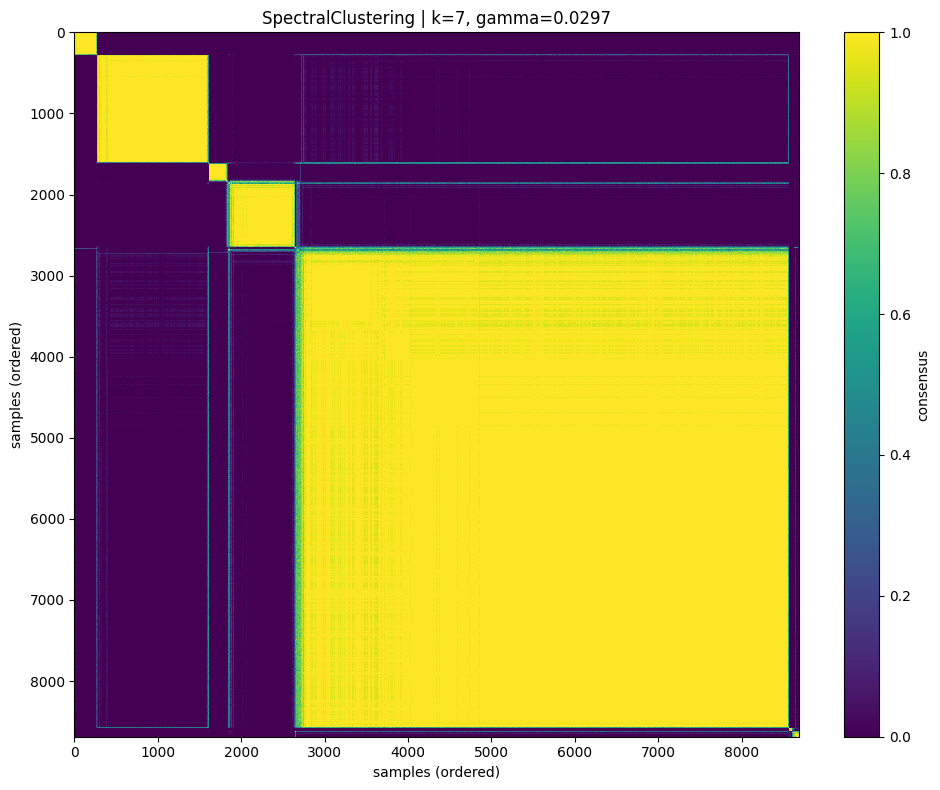

In [24]:
carve.plot_consensus_matrix(measure='generalizability', k=7, rule='1se')

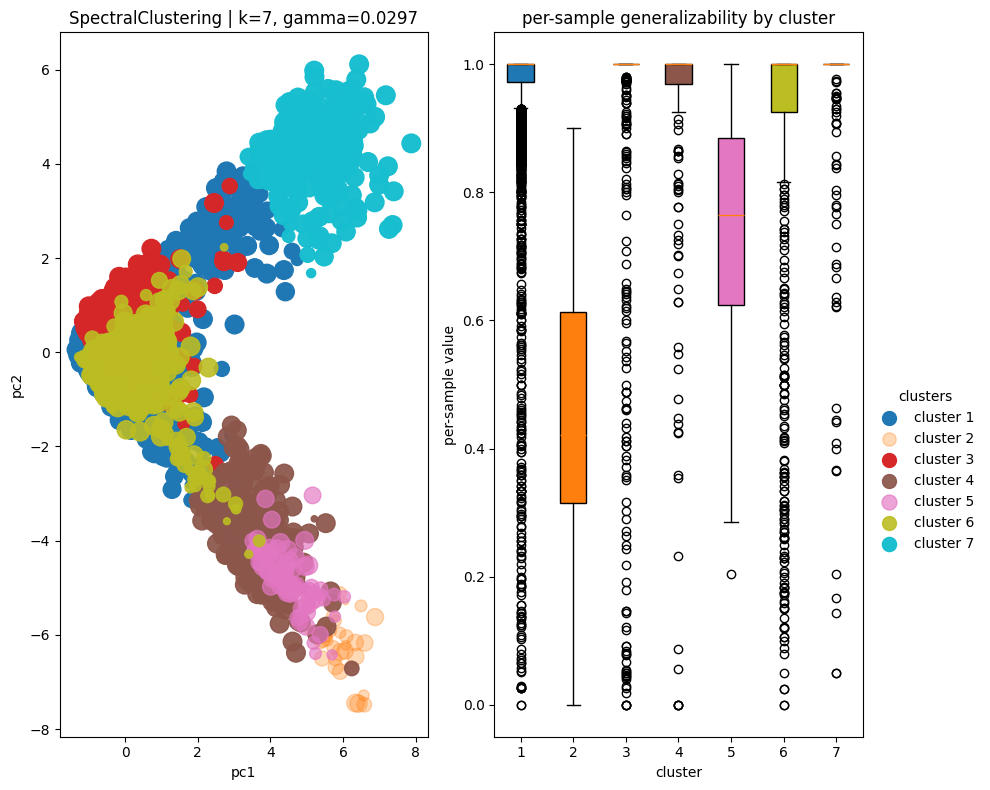

In [26]:
carve.plot_clustering(k=7, measure='generalizability', rule='1se', interactive=False)

In [44]:
# pip if needed:
# %pip install -q plotly kaleido

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

def _unique_in_order(x):
    seen = set()
    out = []
    for v in x:
        if v not in seen:
            out.append(v)
            seen.add(v)
    return out

def _hex_to_rgba(hex_color, a=0.35):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{a})"

def alluvial_compare(
    y_true,
    left_labels,
    right_labels,
    left_title="CARVE (spectral)",
    right_title="silhouette (agg/ward)",
    true_title="true label",
    palette_name="tab10",
    link_alpha=0.35,
    node_pad=20,
    node_thickness=18,
    font_size=14,
    height=600,
    width=1200,
):
    # --- coerce to strings for clean labeling ---
    y_true = pd.Series(y_true).astype(str).to_numpy()
    left_labels = pd.Series(left_labels).astype(int).to_numpy()
    right_labels = pd.Series(right_labels).astype(int).to_numpy()

    n = len(y_true)
    assert len(left_labels) == n and len(right_labels) == n, "length mismatch"

    # --- order true labels by first appearance (closest to how people expect them) ---
    true_order = _unique_in_order(y_true)

    # --- order clusters numerically, show as 1..K ---
    left_order = sorted(np.unique(left_labels))
    right_order = sorted(np.unique(right_labels))

    # --- colors: assign a stable color per TRUE label ---
    cmap = plt.get_cmap(palette_name)
    true_colors = {lab: "#{:02x}{:02x}{:02x}".format(
        int(255*cmap(i % cmap.N)[0]),
        int(255*cmap(i % cmap.N)[1]),
        int(255*cmap(i % cmap.N)[2]),
    ) for i, lab in enumerate(true_order)}

    # --- helper: compute purity + share and dominant true label per predicted cluster ---
    def cluster_stats(pred):
        df = pd.DataFrame({"pred": pred, "true": y_true})
        ct = pd.crosstab(df["pred"], df["true"]).reindex(index=sorted(df["pred"].unique()), columns=true_order, fill_value=0)
        sizes = ct.sum(axis=1).to_numpy()
        shares = sizes / n
        dom_true = ct.idxmax(axis=1).to_numpy()
        purities = (ct.max(axis=1).to_numpy() / np.maximum(sizes, 1))
        return ct, sizes, shares, dom_true, purities

    ct_left, _, share_left, dom_left, pur_left = cluster_stats(left_labels)
    ct_right, _, share_right, dom_right, pur_right = cluster_stats(right_labels)

    # --- node labels (match screenshot style: big purity %, then share %) ---
    left_node_labels = []
    left_node_colors = []
    for i, k in enumerate(left_order):
        purity = pur_left[i]
        share = share_left[i]
        left_node_labels.append(f"{k+1}<br>{purity*100:.0f}%<br>{share*100:.0f}%")
        left_node_colors.append(true_colors[dom_left[i]])

    true_node_labels = [lab for lab in true_order]
    true_node_colors = [true_colors[lab] for lab in true_order]

    right_node_labels = []
    right_node_colors = []
    for i, k in enumerate(right_order):
        purity = pur_right[i]
        share = share_right[i]
        right_node_labels.append(f"{k+1}<br>{purity*100:.0f}%<br>{share*100:.0f}%")
        right_node_colors.append(true_colors[dom_right[i]])

    # --- node indexing ---
    nL = len(left_order)
    nT = len(true_order)
    nR = len(right_order)

    idx_left = {k: i for i, k in enumerate(left_order)}
    idx_true = {lab: nL + i for i, lab in enumerate(true_order)}
    idx_right = {k: nL + nT + i for i, k in enumerate(right_order)}

    # --- links: left -> true and true -> right, colored by TRUE label ---
    sources = []
    targets = []
    values = []
    colors = []

    # left -> true
    for k in left_order:
        for lab in true_order:
            v = int(ct_left.loc[k, lab]) if (k in ct_left.index and lab in ct_left.columns) else 0
            if v > 0:
                sources.append(idx_left[k])
                targets.append(idx_true[lab])
                values.append(v)
                colors.append(_hex_to_rgba(true_colors[lab], link_alpha))

    # true -> right
    ct_tr = pd.crosstab(pd.Series(y_true, name="true"), pd.Series(right_labels, name="pred")).reindex(index=true_order, columns=right_order, fill_value=0)
    for lab in true_order:
        for k in right_order:
            v = int(ct_tr.loc[lab, k])
            if v > 0:
                sources.append(idx_true[lab])
                targets.append(idx_right[k])
                values.append(v)
                colors.append(_hex_to_rgba(true_colors[lab], link_alpha))

    # --- fixed 3-column layout (x positions), evenly spaced y positions per column ---
    def col_positions(m, top=0.02, bottom=0.98):
        if m == 1:
            return [0.5]
        return list(np.linspace(top, bottom, m))

    x = ([0.0]*nL) + ([0.5]*nT) + ([1.0]*nR)
    y = (col_positions(nL)) + (col_positions(nT)) + (col_positions(nR))

    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=node_pad,
            thickness=node_thickness,
            line=dict(color="rgba(0,0,0,0.25)", width=0.5),
            label=left_node_labels + true_node_labels + right_node_labels,
            color=left_node_colors + true_node_colors + right_node_colors,
            x=x,
            y=y,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
        )
    ))

    fig.update_layout(
        font=dict(size=font_size, family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=width,
        height=height,
        margin=dict(l=40, r=40, t=60, b=20),
        annotations=[
            dict(x=0.0, y=1.08, xref="paper", yref="paper", text=left_title, showarrow=False, font=dict(size=font_size+2)),
            dict(x=0.5, y=1.08, xref="paper", yref="paper", text=true_title, showarrow=False, font=dict(size=font_size+2)),
            dict(x=1.0, y=1.08, xref="paper", yref="paper", text=right_title, showarrow=False, font=dict(size=font_size+2)),
        ],
    )
    return fig


In [ ]:
# Agglomerative k=4 (Ward) –– as suggested by silhouette 
agg_labels = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_sub) 

# Spectral, k=7 –– as suggested by CARVE generalizability 
spectral_labels = SpectralClustering(n_clusters=7, gamma=gamma_quantiles_approx(X_sub, qs=(0.50,), random_state=RANDOM_SEED)[0]).fit_predict(X_sub)

fig = alluvial_compare(
    y_true=y_sub,
    left_labels=spectral_labels,   # CARVE choice
    right_labels=agg_labels,       # silhouette choice
    left_title="CARVE (spectral)",
    right_title="silhouette (agg/ward)",
    true_title="true label",
    palette_name="tab10",
    link_alpha=0.35,
)

fig.show()


---